# Example 1 - Pendulum
Originally by Gustavo Café de Miranda, Gubio G. de Lima and Tiago de S. Farias modified by Gang Xu for PSI Scientific Machine Learning class. 
## Finding parameters of differential equations with neural networks

In this notebook, we will go through a step-by-step process of finding parameters of differential equations using deep neural networks. Here we will study the specific case of the pendulum, where we will recover the value of gravity $g$, in the pendulum equation for small angles $$\ddot{\theta} + {\frac{g}{l}}\theta =0 $$.


## Import libraries <span style="color:blue">(no need to change)

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import torch as tc

from tqdm.notebook import tqdm

from torch import nn
from torch.optim.lr_scheduler import StepLR

print(tc.cuda.is_available())
print(tc.cuda.get_device_name(0))

True
NVIDIA GeForce GTX 1660 Ti with Max-Q Design


## Define SHO's analytical solution<span style="color:blue">(no need to change)

In [3]:
def analytical_solution_OHM(x_0, omega_0, t): ###analytical solution of SHO
    return x_0 * tc.cos(omega_0 * t)

## Use the analytical solution of the ODE to create training data <span style="color:blue">(no need to change)

tensor(0.9905)


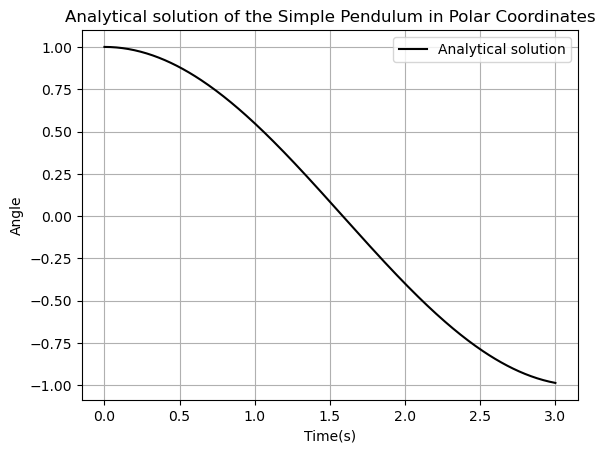

In [4]:
x_0 = 1  # Initial condition
t_i = 0  # Initial time
t_f = 3  # Final time

pendulum_length = tc.tensor(10)  # Length of the pendulum in meters
Omega_0 = tc.sqrt(9.81 / pendulum_length)  # Oscillation frequency
print(Omega_0)

# Creating training data
t_train = tc.linspace(t_i, t_f, 300).reshape(-1, 1)  # Time
theta_train = analytical_solution_OHM(
    x_0=x_0, omega_0=Omega_0, t=t_train
)  # Analytical solution of the OHS

plt.plot(
    t_train.detach().numpy(),
    theta_train.detach().numpy(),
    "k-",
    label="Analytical solution",
)

# Adding labels and title
plt.ylabel("Angle")
plt.xlabel("Time(s)")
plt.title("Analytical solution of the Simple Pendulum in Polar Coordinates")
plt.legend()
plt.grid(True)
plt.show()

## To represent "experimental" data, we will take random values within the analytical solution.<span style="color:blue">(no need to change)

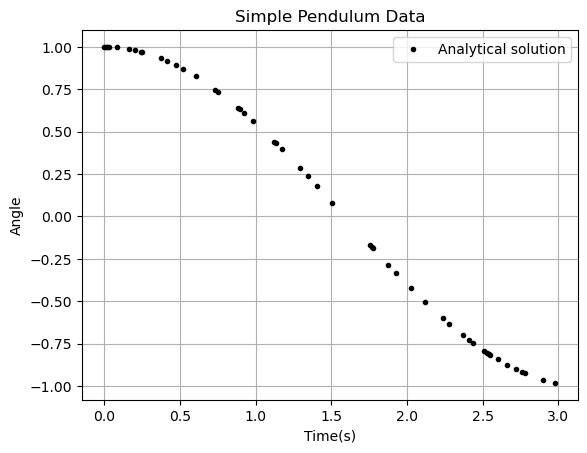

In [5]:
tc.manual_seed(42)  # fixing the random number generator seed
indices = tc.multinomial(
    input=tc.ones(len(t_train)), num_samples=50, replacement=False
)  # len(x_train)//10
t_train_random=t_train[indices]
theta_train_random=theta_train[indices]
plt.plot(
    t_train[indices].detach().numpy(),
    theta_train[indices].detach().numpy(),
    "k.",
    label="Analytical solution",
)

# Adding labels and title
plt.ylabel("Angle")
plt.xlabel("Time(s)")
plt.title("Simple Pendulum Data")
plt.legend()
plt.grid(True)
plt.show()

Our goal is to learn what the acceleration due to gravity is. To do this, we will consider that we know the angle theta at each instant of time, the length of the pendulum, and the initial angle, as represented in the figure above.

Our neural network will represent one of the parameters of the solution:

$$
\theta(t) = \theta_0 \cos(\omega t)
$$
where $\omega = \sqrt{\frac{g}{l}}$, where $g$ is gravity and $l$ is the length of the pendulum.

For our application, we will assume that we do not know the value of $g$, but we will leave the expression in terms of $\omega$. Knowing the value of $\omega$ and $l$, we can obtain $g$ through the expression:

$$
g = \omega^2 \cdot l
$$

Note that this is a very simple objective, the aim is just to illustrate to the reader how we can use the neural network to learn a physical parameter.

Let's initialize the network, declare the optimizer, and also a scheduler, i.e., a function that modifies the learning rate, $\eta$, every specific number of steps.


## Let's define our network<span style="color:blue">(no need to change)

In [6]:
# Defining the neural network


class GravityNet(nn.Module): ### nn.Module is the base class for all NN

    def __init__(self, neurons, M, output=1, activation=None):
        """
        Attributes:
            neurons: Defines the number of neurons in each hidden layer.
            M: Number of hidden layers.
            output: Number of neurons in the output layer.
            activation: The activation function for the hidden layers.
        """
        super(GravityNet, self).__init__() ### super will call its parent class, which is nn.Module ## this runs ini of nn.module enable parameter tracking etc
        self.neurons = neurons ####net (when we make the network )will have attribute neurons
        self.M = M 
        self.output = output

        # List to store the linear layers
        self.hidden_layers = nn.ModuleList([nn.Linear(1, neurons)]) ###module is a list for layers everything inside it is a layer, first hidden layer
        self.hidden_layers.extend([nn.Linear(neurons, neurons) for _ in range(M - 1)])###the hidden layer to hidden layer structure and added (extend) to the modulelist

        # Last linear layer
        self.output_layer = nn.Linear(neurons, output)

        # Activation function
        self.activation = activation

    def forward(self, x):
        for layer in self.hidden_layers:
            x = self.activation(layer(x)) ###layer(x)=w^Tx+b then apply the activation function. 
        x = self.output_layer(x)
        return x




#### Define the NN and the optimizer<span style="color:blue">(no need to change)

In [7]:
tc.manual_seed(2026)  # fixing the random number generator seed


# Defining the neural network
net = GravityNet(neurons=1, M=1, activation=nn.Tanh())
# nn.Sigmoid() or nn.ReLU() or nn.Tanh()

# Loss and optimizer
optimizer = tc.optim.Adam(net.parameters(), lr=0.01)  # defining the optimizer
# lr=0.01 or 0.0001
#optimizer = tc.optim.SGD(net.parameters(), lr=0.01)
#optimizer = tc.optim.RMSprop(net.parameters(), lr=0.001)

# Creating a scheduler to decrease the learning rate every 'step_size' epochs
# scheduler = StepLR(optimizer, step_size=10000, gamma=0.9)

## Start training and at the end output g and error. write code between the zip line

In [8]:
# loss
LOSS = []

# Training
for epoch in tqdm(range(20)):
   #### start with a relative small number of epochs you may want to change later
    omega = net(t_train_random)
    # If we observe the variable "gravity" it is a vector, with size equal to t_train
    # to use it as a parameter it must be just a number
    # Therefore we will take the average of this vector to use as gravity.
   ##################################
    w = tc.mean(omega)
    #################################
    
    theta_NN = x_0 * tc.cos(w * t_train_random)
    
    ###############################################################################3
    loss1 = tc.sum((omega - w) ** 2)
    ######################################################################333333
    loss2 = tc.sum((theta_NN - theta_train_random) ** 2)
############################################################################################################3
   
    
    loss = loss1 + loss2

    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    # scheduler.step()

    LOSS.append(loss.item())

gravity = net(t_train_random)  # Neural network
freq = gravity.mean().detach().numpy()
w=tc.mean(gravity)
theta_NN_plot = x_0 * tc.cos(w * t_train)
print("Value of gravitational acceleration", freq**2 * pendulum_length)
print("Error:", abs(freq**2 * pendulum_length - 9.81))

  0%|          | 0/20 [00:00<?, ?it/s]

Value of gravitational acceleration tensor(8.7796)
Error: tensor(1.0304)


Note that this value is not exactly the value of gravity, it is an approximate value.
$$g \approx g'$$



## Plot the loss and examine how NN perform<span style="color:blue">(no need to change)

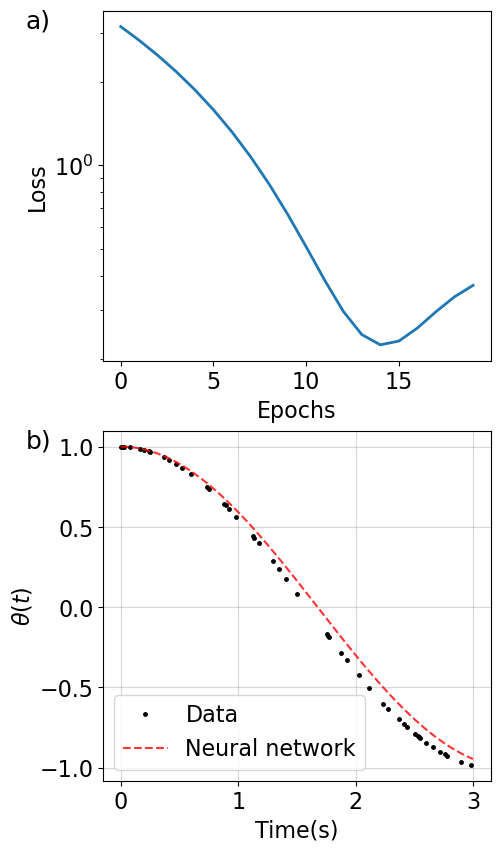

In [9]:
# Setting the font style
plt.rcParams.update({"font.size": 16})

# Creating a figure with two vertical subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(5, 10))

# Subplot a) - Cost function
ax1.plot(LOSS, "-", linewidth=2)
ax1.set_yscale("log")
ax1.set_ylabel("Loss")
ax1.set_xlabel("Epochs")
########ax1.set_xticks([0, 1000, 2000, 3000, 4000, 5000])
#######ax1.set_xlim(-100, 5100)
ax1.text(-0.2, 0.95, "a)", transform=ax1.transAxes, fontsize=18)
# ax1.tick_params(axis='both', which='major')

# Subplot b) - Pendulum Solution
ax2.plot(
    t_train[indices].detach().numpy(),
    theta_train[indices].detach().numpy(),
    "k.",
    markersize=5,
    label="Data",
)
ax2.plot(
    t_train.detach().numpy(),
    theta_NN_plot.detach().numpy(),
    "r--",
    markersize=8, alpha=0.8,
    label="Neural network",
)
ax2.set_ylabel(r"$\theta(t)$")
ax2.set_xlabel("Time(s)")
ax2.grid(True, alpha=0.5)
ax2.legend()
ax2.text(-0.2, 0.95, "b)", transform=ax2.transAxes, fontsize=18)

# Adjusting the spacing between the subplots
# plt.subplots_adjust(hspace=0.3)
# plt.savefig("penduloNN_pt.png", format="png", dpi=500)
plt.show()

## We can use the result to predict the region outside the training domain. Note that in the example above, the time is at most 3 seconds. Let's extend t to 20 seconds and see that the value found for the network parameter is sufficiently close to still be very close to the analytical solution. <span style="color:blue">(no need to change)

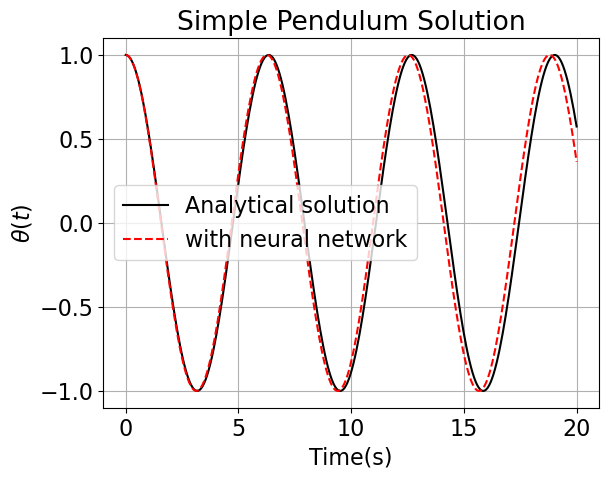

In [10]:
# Creating training data
t_train = tc.linspace(0, 20, 300).reshape(-1, 1)  # Time
theta_train = analytical_solution_OHM(
    x_0=x_0, omega_0=Omega_0, t=t_train
)  # Analytical solution of the OHS

w = tc.mean(net(t_train))
theta_NN = x_0 * tc.cos(w * t_train)

plt.plot(
    t_train.detach().numpy(),
    theta_train.detach().numpy(),
    "k-",
    label="Analytical solution",
)
plt.plot(
    t_train.detach().numpy(),
    theta_NN.detach().numpy(),
    "r--",
    label="with neural network",
)
# Adding labels and title
plt.ylabel(r"$\theta(t)$")
plt.xlabel("Time(s)")
plt.title("Simple Pendulum Solution")
plt.legend()
plt.grid()
plt.show()

# Put it all together, this is the playground. Here you can play with activation function, optimizer and all sorts of stuff.

tensor(0.9905)


  0%|          | 0/5000 [00:00<?, ?it/s]

Value of gravitational acceleration tensor(9.8984)


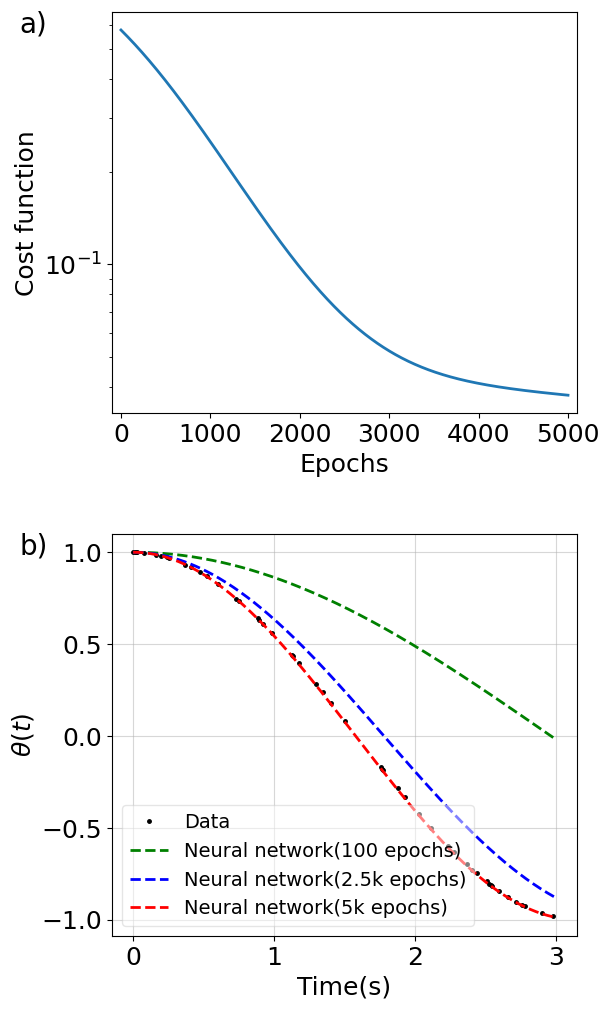

In [11]:
tc.manual_seed(42)  # fixing the random number generator seed

x_0 = 1  # Initial condition
t_i = 0  # Initial time
t_f = 3  # Final time

pendulum_length = tc.tensor(10)  # Length of the pendulum in meters
Omega_0 = tc.sqrt(9.81 / pendulum_length)  # Oscillation frequency
print(Omega_0)

# Creating training data
t_train = tc.linspace(t_i, t_f, 300).reshape(-1, 1)  # Time
theta_train = analytical_solution_OHM(
    x_0=x_0, omega_0=Omega_0, t=t_train
)  # Analytical solution of the OHS

tc.manual_seed(42)  # fixing the random number generator seed
indices = tc.multinomial(
    input=tc.ones(len(t_train)), num_samples=50, replacement=False
)  # len(x_train)//10
t_train_random=t_train[indices]
rand_tensor = tc.randn(50,1)/5
theta_train_random=theta_train[indices]+rand_tensor
# Defining the neural network
net = GravityNet(neurons=1, M=2, activation=nn.Tanh())

# Loss and optimizer
optimizer = tc.optim.Adam(net.parameters(), lr=0.0001)  # defining the optimizer
# SGD or RMSprop or Adam?

# loss
LOSS = []

save_predictions_epoc = []

# Training
for epoch in tqdm(range(5000)):
    omega = net(t_train_random)
    # If we observe the variable "gravity" it is a vector, with size equal to t_train
    # to use it as a parameter it must be just a number
    # Therefore we will take the average of this vector to use as gravity.
    w = tc.mean(omega)

    # theta_neuralnetwork = x_0*tc.cos(tc.sqrt(g/pendulum_length)*t_train)
    theta_NN = x_0 * tc.cos(w * t_train_random)
    loss1 = tc.mean((theta_train_random - theta_NN) ** 2)

    # we can impose that, regardless of the input, the parameter must be the same
    loss2 = tc.mean(abs(omega - w))
    loss = loss1 + loss2

    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

    LOSS.append(loss.item())

    if epoch == 100:
        theta_epoch= x_0 * tc.cos(w * t_train)
        save_predictions_epoc.append(theta_epoch.detach().numpy())
    if epoch == 2500:
        theta_epoch= x_0 * tc.cos(w * t_train)
        save_predictions_epoc.append(theta_epoch.detach().numpy())


gravity = net(t_train)  # Neural network
freq = gravity.mean().detach().numpy()
print("Value of gravitational acceleration", freq**2 * pendulum_length)
w=tc.mean(gravity)
theta_NN = x_0 * tc.cos(w * t_train)
# Configurando o estilo da fonte
plt.rcParams.update({"font.size": 18})

# Criando uma figura com dois subplots verticais
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 12))

# Subplot a) - Função custo
ax1.plot(LOSS, "-", linewidth=2)
ax1.set_yscale("log")
ax1.set_ylabel("Cost function")
ax1.set_xlabel("Epochs")
ax1.set_xticks([0, 1000, 2000, 3000, 4000, 5000])
ax1.set_xlim(-100, 5100)
ax1.text(-0.2, 0.95, "a)", transform=ax1.transAxes, fontsize=20)
# ax1.tick_params(axis='both', which='major')

# Subplot b) - Solução do Pêndulo
ax2.plot(
    t_train[indices].detach().numpy(),
    theta_train[indices].detach().numpy(),
    "k.",
    markersize=5,
    label="Data",
)

ax2.plot(
    t_train.detach().numpy(),
    save_predictions_epoc[0],
    "g--",
    linewidth=2,
    label="Neural network(100 epochs)",
)
ax2.plot(
    t_train.detach().numpy(),
    save_predictions_epoc[1],
    "b--",
    linewidth=2,
    label="Neural network(2.5k epochs)",
)
ax2.plot(
    t_train.detach().numpy(),
    theta_NN.detach().numpy(),
    "r--",
    linewidth=2,
    label="Neural network(5k epochs) ",
)
ax2.set_ylabel(r"$\theta(t)$")
ax2.set_xlabel("Time(s)")
ax2.grid(True, alpha=0.5)
leg = ax2.legend(fontsize=14, loc="lower left")
leg.get_frame().set_alpha(0.5)
ax2.text(-0.2, 0.95, "b)", transform=ax2.transAxes, fontsize=20)

# Ajustando o espaçamento entre os subplots
plt.subplots_adjust(hspace=0.3)
plt.show()